# Data Mining Project 2 

Modules:
1. data understanding and preparation
2. outlier analysis and treatment
3. imbalanced learning strategies
4. advanced classification (multiclass target `sii`)
5. model explainability and error analysis
6. additional advanced tasks: regression and clustering


In [1]:
# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression
from sklearn.experimental import enable_iterative_imputer

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42


## 1. Data Loading

Dataset files used:
- `cmi_internet.csv`
- `data_dictionary.csv`


In [2]:
# Resolve file paths (project-relative first)
data_path_rel = Path('dm2_25_26_dataset_tabular/DM2_project/cmi_internet.csv')
dict_path_rel = Path('dm2_25_26_dataset_tabular/DM2_project/data_dictionary.csv')

data_path_fallback = Path('C:/Users/steve/Downloads/Data_Mining_project2/dm2_25_26_dataset_tabular/DM2_project/cmi_internet.csv')
dict_path_fallback = Path('C:/Users/steve/Downloads/Data_Mining_project2/dm2_25_26_dataset_tabular/DM2_project/data_dictionary.csv')

if data_path_rel.exists():
    data_path = data_path_rel
elif data_path_fallback.exists():
    data_path = data_path_fallback
else:
    raise FileNotFoundError('Dataset file not found')

if dict_path_rel.exists():
    dict_path = dict_path_rel
elif dict_path_fallback.exists():
    dict_path = dict_path_fallback
else:
    dict_path = None

df = pd.read_csv(data_path)
df_original = df.copy()

print('Data path:', data_path)
print('Shape:', df.shape)
df.head()


Data path: dm2_25_26_dataset_tabular\DM2_project\cmi_internet.csv
Shape: (8460, 82)


,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,2,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,3,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,4,Spring,18,1,Summer,65.0,NaN,17.937682,NaN,77.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,1.0,0.0


In [3]:
# Optional: read data dictionary for feature semantics
if dict_path is not None:
    data_dictionary = pd.read_csv(dict_path)
    print('Data dictionary shape:', data_dictionary.shape)
    display(data_dictionary)
else:
    print('Data dictionary not found.')


Data dictionary shape: (81, 6)


,Instrument,Field,Description,Type,Values,Value Labels
0,Identifier,id,Participant's ID,str,NaN,NaN
1,Demographics,Basic_Demos-Enroll_Season,Season of enrollment,str,"Spring, Summer, Fall, Winter",NaN
2,Demographics,Basic_Demos-Age,Age of participant,float,NaN,NaN
3,Demographics,Basic_Demos-Sex,Sex of participant,categorical int,"0,1","0=Male, 1=Female"
4,Children's Global Assessment Scale,CGAS-Season,Season of participation,str,"Spring, Summer, Fall, Winter",NaN
...,...,...,...,...,...,...
76,Sleep Disturbance Scale,SDS-Season,Season of participation,str,"Spring, Summer, Fall, Winter",NaN
77,Sleep Disturbance Scale,SDS-SDS_Total_Raw,Total Raw Score,int,NaN,NaN
78,Sleep Disturbance Scale,SDS-SDS_Total_T,Total T-Score,int,NaN,NaN
79,Internet Use,PreInt_EduHx-Season,Season of participation,str,"Spring, Summer, Fall, Winter",NaN


## 2. Data Understanding and Preparation


In [4]:
df.info()

print('Number of duplicated rows:', df.duplicated().sum())
print('Number of columns:', df.shape[1])
print('Number of records:', df.shape[0])

target_col = 'sii'
id_col = 'id' if 'id' in df.columns else None

print('Target column:', target_col)
print('ID column:', id_col)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8460 entries, 0 to 8459
Data columns (total 82 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      8460 non-null   int64  
 1   Basic_Demos-Enroll_Season               8460 non-null   object 
 2   Basic_Demos-Age                         8460 non-null   int64  
 3   Basic_Demos-Sex                         8460 non-null   int64  
 4   CGAS-Season                             7158 non-null   object 
 5   CGAS-CGAS_Score                         7034 non-null   float64
 6   Physical-Season                         7858 non-null   object 
 7   Physical-BMI                            7591 non-null   float64
 8   Physical-Height                         7595 non-null   float64
 9   Physical-Weight                         7641 non-null   float64
 10  Physical-Waist_Circumference            5624 non-null   floa

In [5]:
# Missing values profile
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).sort_values(ascending=False)  # Missing percentage

print('Columns with missing values:', int((missing_count > 0).sum()))
print('Top missing columns:')
missing_pct.head(20).to_frame('missing_pct')


Columns with missing values: 77
Top missing columns:


,missing_pct
PCIAT-PCIAT_02,67.919622
PCIAT-Season,67.919622
PCIAT-PCIAT_08,67.919622
PCIAT-PCIAT_09,67.919622
PCIAT-PCIAT_10,67.919622
PCIAT-PCIAT_06,67.919622
PCIAT-PCIAT_05,67.919622
PCIAT-PCIAT_01,67.919622
PCIAT-PCIAT_04,67.919622
PCIAT-PCIAT_11,67.919622


**Numerical Atributes**

In [6]:
# Check the correlation between features and target
numerical_cols = df.select_dtypes(include=['number'])
print('Numericals Attributes', len(numerical_cols.columns))
numerical_cols

Numericals Attributes 71


,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,...,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii
0,0,5,0,51.0,16.877316,46.00,50.8,26.00,NaN,NaN,...,4.0,4.0,4.0,2.0,4.0,55.0,NaN,NaN,3.0,2.0
1,1,9,0,NaN,14.035590,48.00,46.0,22.00,75.0,70.0,...,0.0,0.0,0.0,0.0,0.0,0.0,46.0,64.0,0.0,0.0
2,2,10,1,71.0,16.648696,56.50,75.6,NaN,65.0,94.0,...,0.0,2.0,2.0,1.0,1.0,28.0,38.0,54.0,2.0,0.0
3,3,9,0,71.0,18.292347,56.00,81.6,26.00,60.0,97.0,...,3.0,4.0,3.0,4.0,1.0,44.0,31.0,45.0,0.0,1.0
4,4,18,1,65.0,17.937682,NaN,77.0,26.00,68.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,8455,7,1,NaN,16.130585,46.07,49.0,22.25,58.5,82.5,...,NaN,NaN,NaN,NaN,NaN,NaN,38.5,55.0,0.0,0.0
8456,8456,10,1,69.5,NaN,56.13,47.8,28.50,66.0,80.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0
8457,8457,10,1,70.0,40.937571,49.56,47.2,NaN,63.5,83.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0
8458,8458,15,1,55.5,NaN,63.79,99.5,31.10,NaN,87.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0


In [7]:
numerical_cols.describe()

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,...,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii
count,8460.000000,8460.000000,8460.000000,7034.000000,7591.000000,7595.000000,7641.000000,5624.000000,7528.000000,7539.000000,...,2714.000000,2714.000000,2714.000000,2714.000000,2714.000000,2714.000000,4903.000000,4903.000000,7849.000000,8460.000000
mean,4229.500000,10.240189,0.402364,67.021041,19.532651,57.189069,84.428737,26.959113,68.937566,81.894150,...,1.447310,1.621592,1.611275,1.157701,0.940310,27.855195,41.410667,58.072813,0.981144,0.443853
std,2442.335972,3.574680,0.490404,35.284140,4.683925,7.374577,40.218441,3.821844,11.162469,11.380533,...,1.491957,1.443668,1.525420,1.340968,1.181054,20.318784,9.464932,12.563287,1.046645,0.731014
min,0.000000,5.000000,0.000000,25.000000,0.000000,33.000000,0.000000,18.000000,0.000000,27.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,38.000000,0.000000,0.000000
25%,2114.750000,7.000000,0.000000,60.500000,16.541742,51.500000,55.200000,25.000000,62.500000,75.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,35.000000,50.000000,0.000000,0.000000
50%,4229.500000,10.000000,0.000000,65.000000,17.937682,55.700000,75.000000,26.000000,68.000000,81.500000,...,1.000000,1.000000,1.000000,1.000000,1.000000,26.000000,39.500000,55.000000,1.000000,0.000000
75%,6344.250000,12.000000,1.000000,70.500000,21.469546,63.000000,107.000000,28.250000,72.500000,87.000000,...,2.000000,3.000000,2.000000,2.000000,1.000000,41.000000,45.000000,62.500000,2.000000,1.000000
max,8459.000000,22.000000,1.000000,999.000000,59.132048,78.500000,315.000000,50.000000,179.000000,138.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,93.000000,96.000000,100.000000,3.000000,3.000000


In [21]:
print("Value counts for 'sii' column:")
print(df['sii'].value_counts())

Value counts for 'sii' column:
sii
0.0    5833
1.0    1587
2.0     952
3.0      88
Name: count, dtype: int64


**Categorical Attributes**

In [8]:
categorical_cols = df.select_dtypes(include=['object'])
print('Categorical Attributes', len(categorical_cols.columns))
categorical_cols

Categorical Attributes 11


,Basic_Demos-Enroll_Season,CGAS-Season,Physical-Season,Fitness_Endurance-Season,FGC-Season,BIA-Season,PAQ_A-Season,PAQ_C-Season,PCIAT-Season,SDS-Season,PreInt_EduHx-Season
0,Fall,Winter,Fall,Spring,Fall,Fall,Winter,NaN,Fall,NaN,Fall
1,Summer,NaN,Fall,NaN,Fall,Winter,Winter,Fall,Fall,Fall,Summer
2,Summer,Fall,Fall,Fall,Fall,NaN,NaN,Summer,Fall,Fall,Summer
3,Winter,Fall,Summer,Summer,Summer,Summer,NaN,Winter,Summer,Summer,Winter
4,Spring,Summer,NaN,Spring,NaN,NaN,Summer,Spring,NaN,NaN,Spring
...,...,...,...,...,...,...,...,...,...,...,...
8455,Spring,Spring,Fall,NaN,Summer,Fall,Winter,Spring,NaN,Summer,Spring
8456,Winter,Spring,Winter,NaN,Summer,Spring,Winter,Winter,NaN,NaN,Winter
8457,Winter,Winter,Winter,NaN,Winter,Summer,NaN,NaN,NaN,NaN,Spring
8458,Fall,NaN,Spring,NaN,Fall,NaN,NaN,Summer,NaN,NaN,Fall


In [10]:
categorical_cols.describe()

,Basic_Demos-Enroll_Season,CGAS-Season,Physical-Season,Fitness_Endurance-Season,FGC-Season,BIA-Season,PAQ_A-Season,PAQ_C-Season,PCIAT-Season,SDS-Season,PreInt_EduHx-Season
count,8460,7158,7858,6004,7891,6778,5231,6385,2714,4903,8071
unique,4,4,4,4,4,4,4,4,4,4,4
top,Spring,Spring,Spring,Spring,Spring,Summer,Winter,Spring,Spring,Spring,Spring
freq,2447,2561,2726,3278,2722,2751,4482,3406,761,1585,2482


**Continuous Attributes Distribution**

In [15]:
numerical_cols.columns

Index(['id', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score',
       'Physical-BMI', 'Physical-Height', 'Physical-Weight',
       'Physical-Waist_Circumference', 'Physical-Diastolic_BP',
       'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Max_Stage', 'Fitness_Endurance-Time_Mins',
       'Fitness_Endurance-Time_Sec', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone',
       'FGC-FGC_GSND', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone',
       'FGC-FGC_PU', 'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone',
       'FGC-FGC_SRR', 'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'PAQ_A-PAQ_A_Total', 'PAQ_C-PAQ_C_Total',
       'PCIAT-PCIAT_01', 'PCIAT-PCIAT_02', 'P

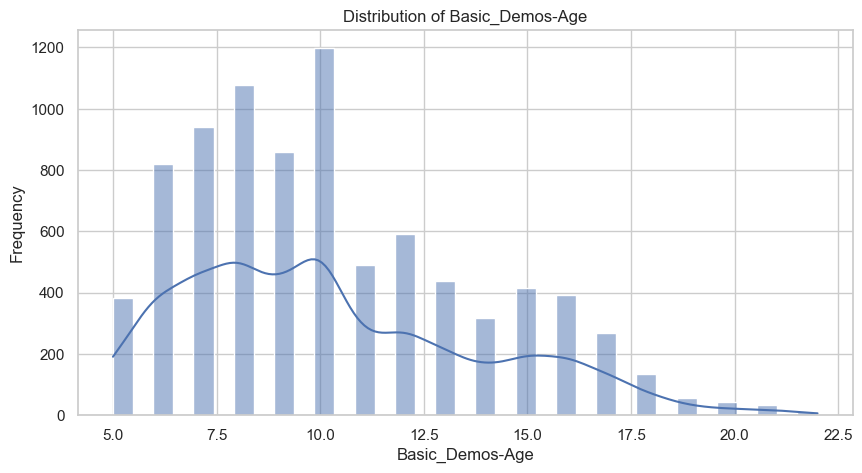

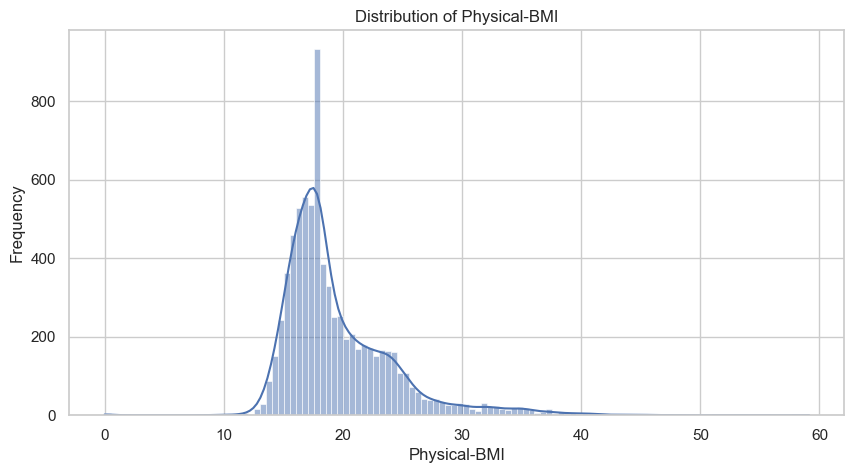

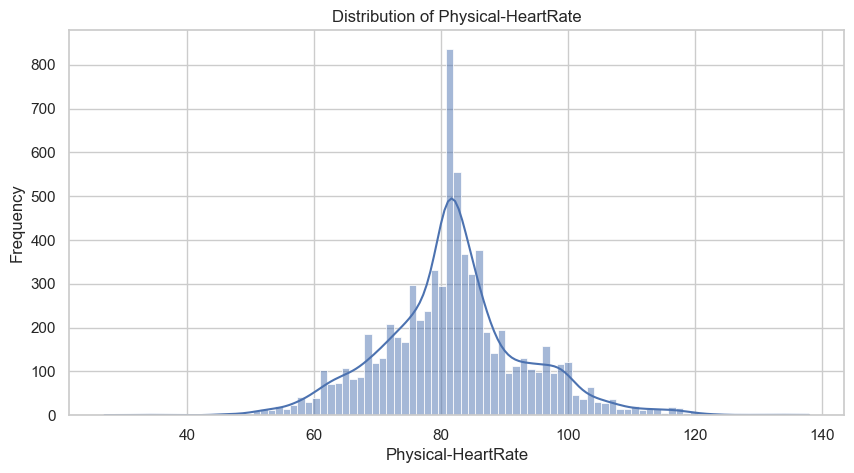

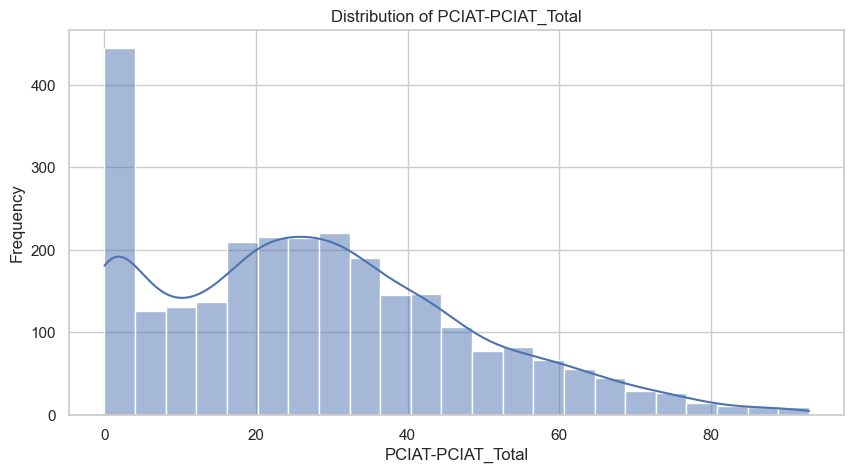

In [17]:
# distrubution top 5 continuous variables
continuous_features = df[['Basic_Demos-Age', 'Physical-BMI', 'Physical-HeartRate','PCIAT-PCIAT_Total']]
for feature in continuous_features:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

**Target variable distribution (sii)**

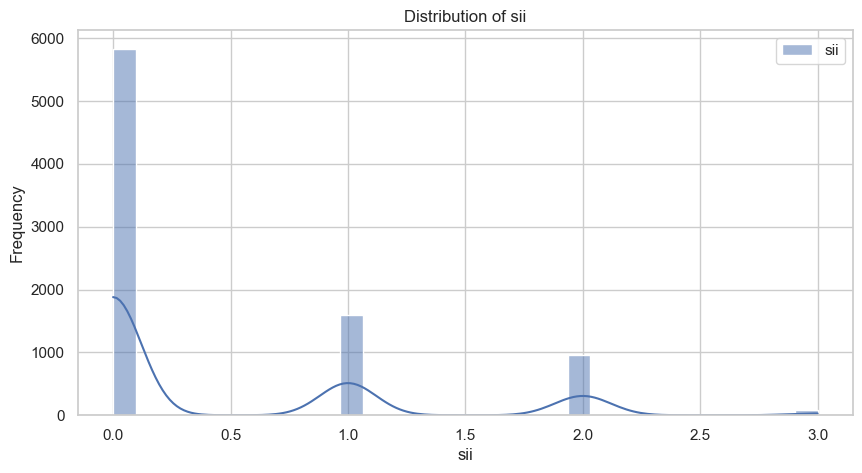

In [ ]:
target_feature = ['sii'] # Assuming that sii is the target variable we want to predict and is datatype numercial ordinal

plt.figure(figsize=(10, 5))
sns.histplot(df[target_feature], kde=True)
plt.title(f'Distribution of {target_feature[0]}')
plt.xlabel(target_feature[0])
plt.ylabel('Frequency')
plt.show()

**Boxplot of certains continuous attributes**

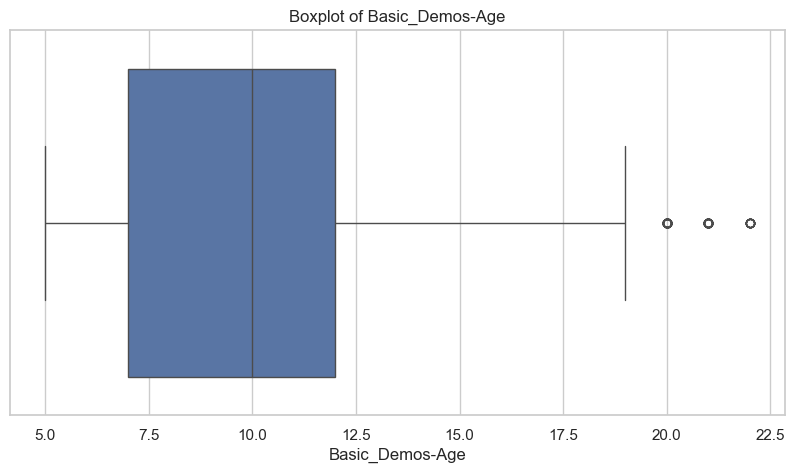

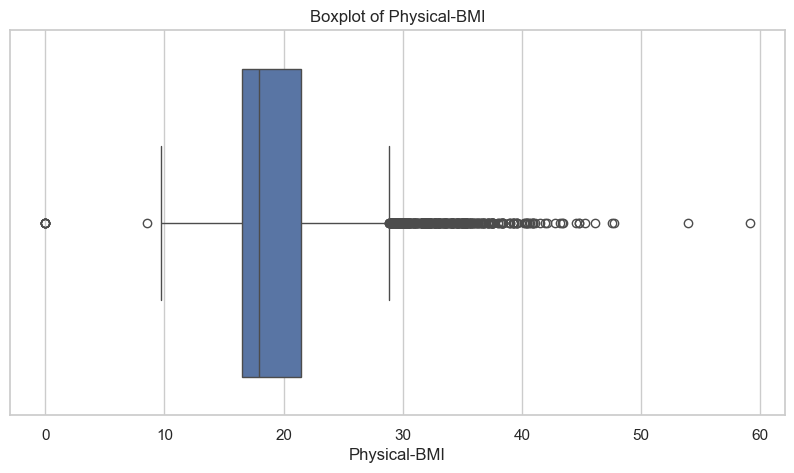

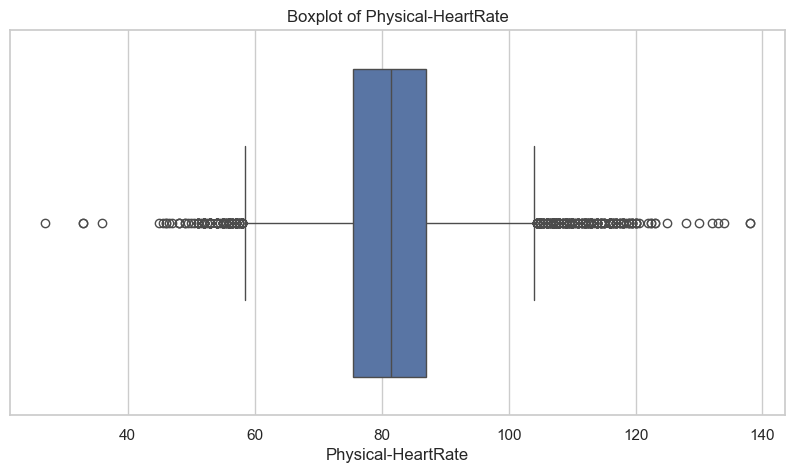

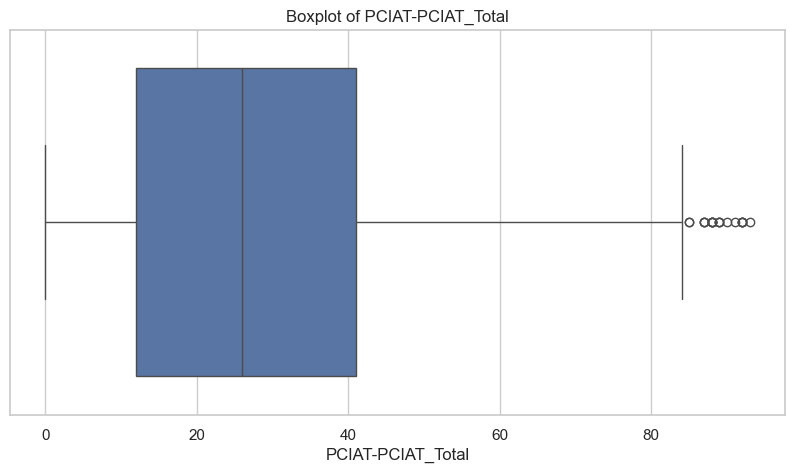

In [20]:
# Boxplot for top 5 continuous variables
for feature in continuous_features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.xlabel(feature)
    plt.show()

### Correlation

In [23]:
numerical_df = df.select_dtypes(include=['number'])
numerical_df.corr(method = "spearman")

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,...,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii
id,1.000000,-0.042365,0.055418,0.040280,0.092730,0.148934,-0.079089,0.068037,-0.034049,0.043883,...,0.004315,-0.001170,-0.007948,-0.028266,-0.005692,0.001102,0.088401,0.062524,-0.057547,0.003335
Basic_Demos-Age,-0.042365,1.000000,0.002142,0.033700,0.496651,0.758324,0.719282,0.543777,0.149155,-0.240856,...,0.121321,0.313877,0.181396,0.336318,0.333485,0.430515,0.025086,0.030683,0.385474,0.219301
Basic_Demos-Sex,0.055418,0.002142,1.000000,0.079162,0.010384,-0.015829,-0.032755,-0.020455,0.013360,0.028542,...,-0.088709,-0.094693,-0.098157,-0.095798,-0.055216,-0.089870,-0.028623,-0.027113,-0.007203,-0.079186
CGAS-CGAS_Score,0.040280,0.033700,0.079162,1.000000,-0.013581,0.040829,-0.006884,0.033236,-0.021012,-0.023769,...,-0.028394,-0.023633,-0.035977,-0.027269,-0.033434,-0.042407,-0.122391,-0.116452,-0.045458,-0.036745
Physical-BMI,0.092730,0.496651,0.010384,-0.013581,1.000000,0.551686,0.694170,0.542201,0.176959,-0.075377,...,0.081746,0.173592,0.106829,0.190385,0.165396,0.251392,0.071497,0.049644,0.288058,0.126242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PCIAT-PCIAT_Total,0.001102,0.430515,-0.089870,-0.042407,0.251392,0.421308,0.382161,0.184156,0.075513,-0.039915,...,0.767822,0.824882,0.796719,0.748349,0.748367,1.000000,0.237655,0.236687,0.367035,0.882557
SDS-SDS_Total_Raw,0.088401,0.025086,-0.028623,-0.122391,0.071497,0.041045,0.040692,0.044143,0.001541,0.057321,...,0.232183,0.184851,0.229253,0.154136,0.173477,0.237655,1.000000,0.845824,0.060569,0.194951
SDS-SDS_Total_T,0.062524,0.030683,-0.027113,-0.116452,0.049644,0.037252,0.037507,0.041640,-0.006061,0.046399,...,0.231400,0.184272,0.228594,0.153414,0.172469,0.236687,0.845824,1.000000,0.063656,0.191099
PreInt_EduHx-computerinternet_hoursday,-0.057547,0.385474,-0.007203,-0.045458,0.288058,0.359765,0.382485,0.291740,0.106715,-0.103928,...,0.181336,0.295954,0.217197,0.289461,0.256129,0.367035,0.060569,0.063656,1.000000,0.207995


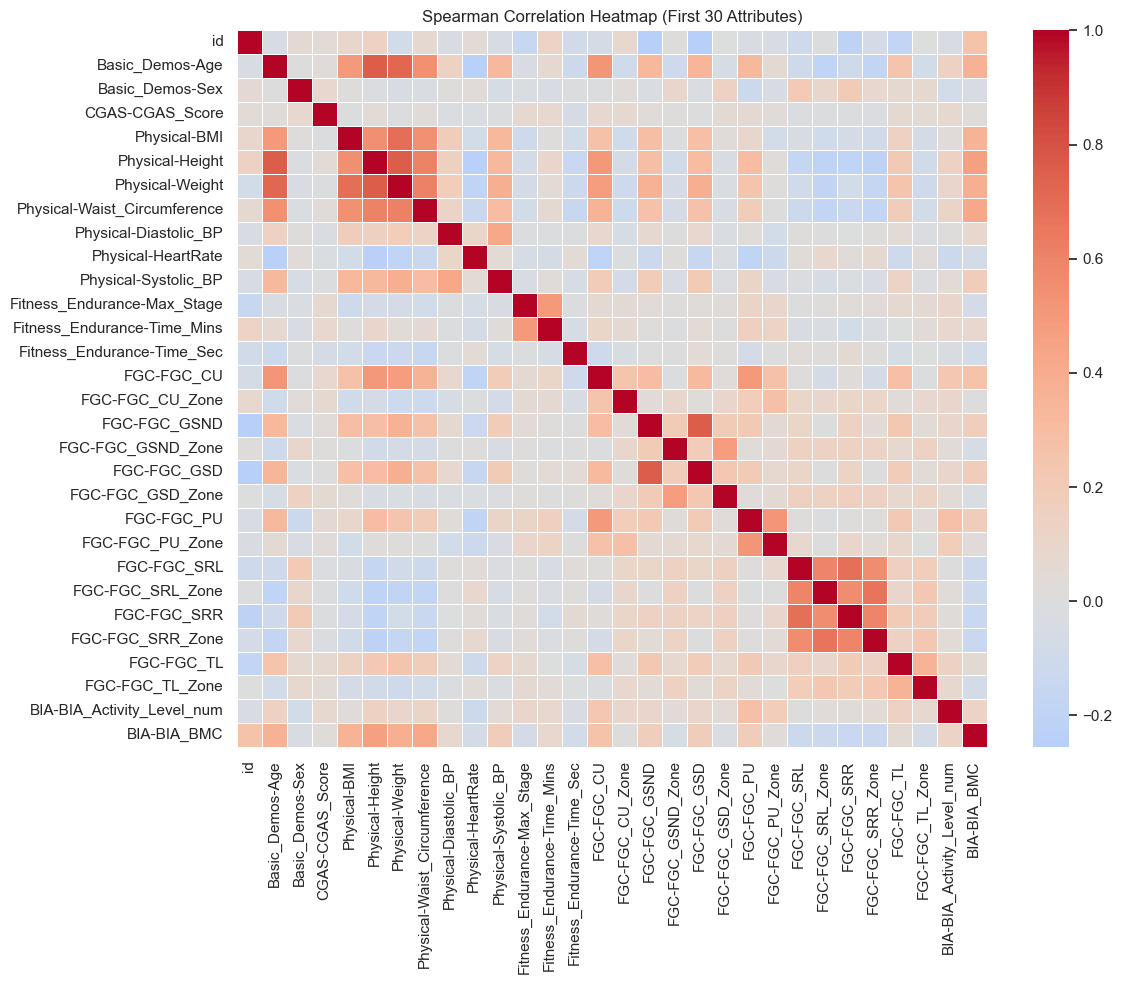

In [ ]:
# First 30 attributes (columns)
numerical_df1_30 = numerical_df.iloc[:, :30]
corr_matrix = numerical_df1_30.corr(method="spearman")

plt.figure(figsize=(12, 10))

# Heatmap
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap="coolwarm", 
            center=0, 
            linewidths=0.5)

plt.title("Spearman Correlation Heatmap (First 30 Attributes)")
plt.tight_layout()
plt.show()

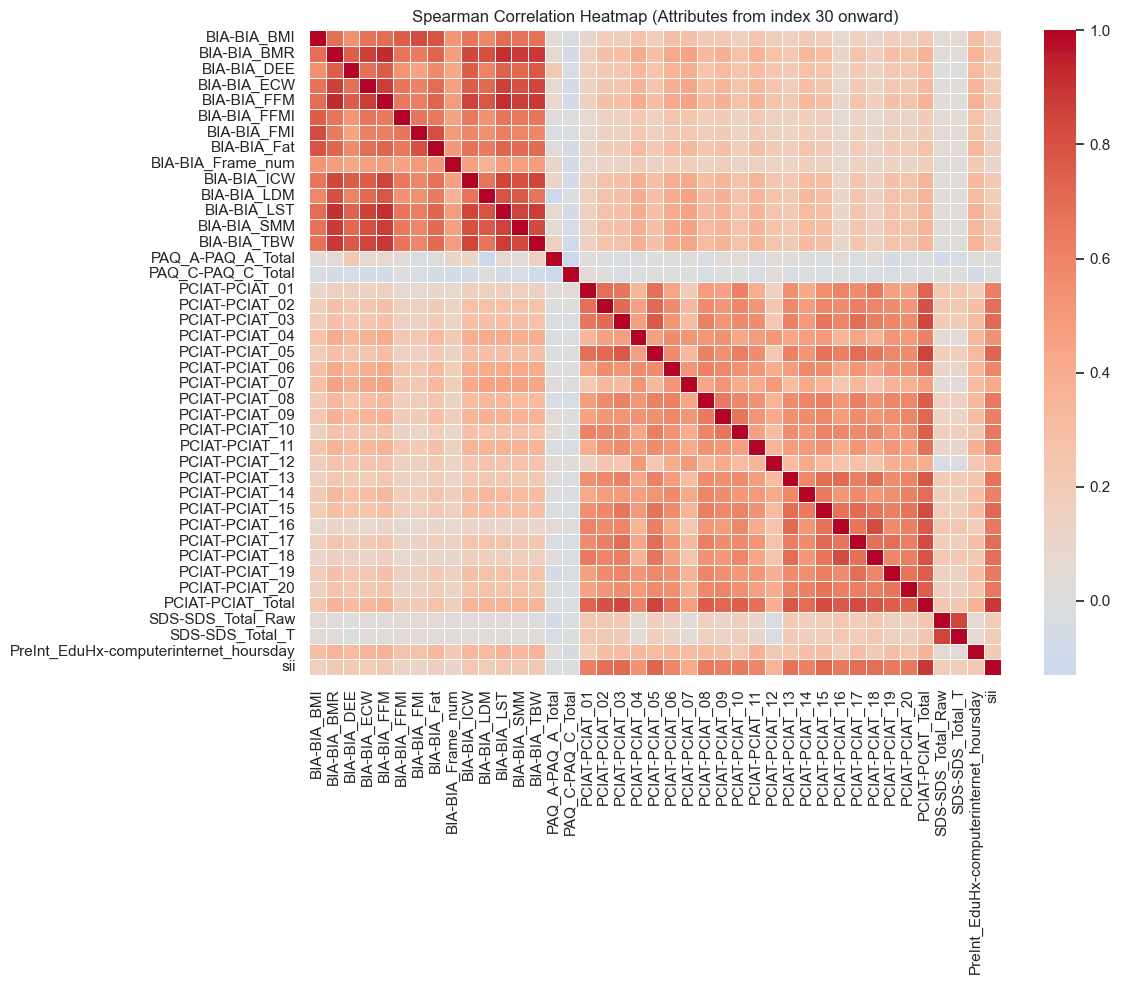

In [38]:
numerical_df_rest = numerical_df.iloc[:, 30:]

# Calcola matrice di correlazione Spearman
corr_matrix = numerical_df_rest.corr(method="spearman")

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, 
            annot=False, 
            cmap="coolwarm", 
            center=0, 
            linewidths=0.5)

plt.title("Spearman Correlation Heatmap (Attributes from index 30 onward)")
plt.tight_layout()
plt.show()

**Correlation assuming a target attribute**

In [40]:
#considering it was a bother to look at the values as an exercise I wrote a function to extract the most correlated ones
def corr_info(data_frame, input_corr_value = 0.4, method_apply = 'pearson', call = None):
    correlated = data_frame.corr(method = method_apply)
    for i in correlated.values:
        for x in i: # i is an array, iterate for all its elements
            if abs(x) < input_corr_value or x == 1.0: # Set correlation values below input_corr_value or self-correlations to NaN
                correlated = correlated.replace({x: np.nan})
    hypercorrelated = correlated.dropna(how='all').T.dropna(how='all').T # DataFrame with only highly correlated rows and columns

    # lista will store the values extracted from the "hypercorrelated" dataframe
    lista = []

    for i in hypercorrelated.columns:
        row_correlated = str(hypercorrelated[i].dropna()) # For each column, save only the non-null values
        rows = row_correlated[0:row_correlated.find('\nName')] # Just to get rid of the useless text (Series name)
        lista.append(str(i) + "(column)" + ":\n" + str(rows)) # It adds to lista the column marker and the row value


    # The following was done in order to create the dictionary output of the function
    dict_output = dict(s.split("(column)") for s in [i.replace(":\n", "") for i in lista]) # I delete the marker
    for key, value in dict_output.items():
        # to iterate between clean key values "s" in order to create nested dictionaries of the rows
        dict_output[key] = dict(s.split() for s in [i for i in dict_output[key].split("\n")])

    # Find unique values (beyond the input threshold) inside the "hypercorrelated" dataframe and set the string output
    concatenate_unique_arrays = np.concatenate([hypercorrelated[i].unique() for i in hypercorrelated.columns])
    hcorr = pd.Series(concatenate_unique_arrays).dropna().unique()
    num_of_hcorr = len(hcorr)
    stringa_output = "Number of highly correlated variables (greater than {} with the {} method):\n".format(input_corr_value, method_apply)+ str(num_of_hcorr) + '\n\n' + "Unique values:" + '\n\n' + str(hcorr) + '\n\n' + '\n\n'.join(lista)

    # Change NaN into '*' to enhance visualization of the "hypercorrelated" dataframe
    for i in hypercorrelated.values:
        for x in i:
            if np.isnan(x):
                hypercorrelated = hypercorrelated.replace({x: '*'})

    # Set a dictionary with the string, dictionary and dataframe outputs
    outme = {'str' : stringa_output, 'dict': dict_output, 'df' : hypercorrelated}

    # Return either one of them (call parameter) or the dictionary itself
    if call in ['str', 'dict', 'df']:
        return outme[call]
    elif call == None:
        return outme
    else:
        return outme

In [46]:
# I extract the variables correlated monotonically with 'GameWeight' with a value higher than 0.5 in absolute terms
corr_info(numerical_df, 0.5, "spearman", "dict")["BIA-BIA_LST"]

{'Basic_Demos-Age': '0.714083',
 'Physical-BMI': '0.625880',
 'Physical-Height': '0.773750',
 'Physical-Weight': '0.776016',
 'Physical-Waist_Circumference': '0.606332',
 'BIA-BIA_BMI': '0.696532',
 'BIA-BIA_BMR': '0.917014',
 'BIA-BIA_DEE': '0.740670',
 'BIA-BIA_ECW': '0.865838',
 'BIA-BIA_FFM': '0.918434',
 'BIA-BIA_FFMI': '0.665330',
 'BIA-BIA_FMI': '0.630514',
 'BIA-BIA_Fat': '0.729713',
 'BIA-BIA_ICW': '0.843465',
 'BIA-BIA_LDM': '0.788107',
 'BIA-BIA_SMM': '0.858129',
 'BIA-BIA_TBW': '0.868933'}

**Variable to delete**

*BIA-BIA_LST*
- "BIA-BIA_BMR" 0.91
- "BIA-BIA_FFM" 0.91
- "BIA-BIA_ECW" 0.86
- "BIA-BIA_TBW" 0.86
- "BIA-BIA_SMM" 0.85

**Variance Threshold**

In [18]:
# Numerical features
numerical_df = df.select_dtypes(include=['number'])

In [19]:

df_treshold = pd.DataFrame(numerical_df)
# 2. Initialisation du seuil
# threshold=0 : supprime uniquement les colonnes constantes
# threshold=0.1 : supprime les colonnes où la variance est < 0.1
selector = VarianceThreshold(threshold=0.1)

# 3. Application du filtre
df_reduced = selector.fit_transform(df_treshold)

# 4. Récupération des noms de colonnes conservées
# (VarianceThreshold renvoie un array Numpy, on le repasse en DataFrame)
selected_columns = df_treshold.columns[selector.get_support()]
df_final = pd.DataFrame(df_reduced, columns=selected_columns)

# Pour voir ce qui a été supprimé :
dropped_columns = [col for col in df_treshold.columns if col not in selected_columns]

In [20]:
# How many variables explain the variance treshold = 0.1
df_final

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,...,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii
0,0.0,5.0,0.0,51.0,16.877316,46.00,50.8,26.00,NaN,NaN,...,4.0,4.0,4.0,2.0,4.0,55.0,NaN,NaN,3.0,2.0
1,1.0,9.0,0.0,NaN,14.035590,48.00,46.0,22.00,75.0,70.0,...,0.0,0.0,0.0,0.0,0.0,0.0,46.0,64.0,0.0,0.0
2,2.0,10.0,1.0,71.0,16.648696,56.50,75.6,NaN,65.0,94.0,...,0.0,2.0,2.0,1.0,1.0,28.0,38.0,54.0,2.0,0.0
3,3.0,9.0,0.0,71.0,18.292347,56.00,81.6,26.00,60.0,97.0,...,3.0,4.0,3.0,4.0,1.0,44.0,31.0,45.0,0.0,1.0
4,4.0,18.0,1.0,65.0,17.937682,NaN,77.0,26.00,68.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,8455.0,7.0,1.0,NaN,16.130585,46.07,49.0,22.25,58.5,82.5,...,NaN,NaN,NaN,NaN,NaN,NaN,38.5,55.0,0.0,0.0
8456,8456.0,10.0,1.0,69.5,NaN,56.13,47.8,28.50,66.0,80.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0
8457,8457.0,10.0,1.0,70.0,40.937571,49.56,47.2,NaN,63.5,83.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0
8458,8458.0,15.0,1.0,55.5,NaN,63.79,99.5,31.10,NaN,87.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0


In [21]:
# How many variable have been removed with the variance treshold = 0.1
len(dropped_columns)
dropped_columns

[]

**Summary all variable explain something and then are important for our analysis**

**Missing Values handling**

In [22]:
# Distribution of features before imputation
numerical_df.describe()


,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,...,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii
count,8460.000000,8460.000000,8460.000000,7034.000000,7591.000000,7595.000000,7641.000000,5624.000000,7528.000000,7539.000000,...,2714.000000,2714.000000,2714.000000,2714.000000,2714.000000,2714.000000,4903.000000,4903.000000,7849.000000,8460.000000
mean,4229.500000,10.240189,0.402364,67.021041,19.532651,57.189069,84.428737,26.959113,68.937566,81.894150,...,1.447310,1.621592,1.611275,1.157701,0.940310,27.855195,41.410667,58.072813,0.981144,0.443853
std,2442.335972,3.574680,0.490404,35.284140,4.683925,7.374577,40.218441,3.821844,11.162469,11.380533,...,1.491957,1.443668,1.525420,1.340968,1.181054,20.318784,9.464932,12.563287,1.046645,0.731014
min,0.000000,5.000000,0.000000,25.000000,0.000000,33.000000,0.000000,18.000000,0.000000,27.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,38.000000,0.000000,0.000000
25%,2114.750000,7.000000,0.000000,60.500000,16.541742,51.500000,55.200000,25.000000,62.500000,75.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,35.000000,50.000000,0.000000,0.000000
50%,4229.500000,10.000000,0.000000,65.000000,17.937682,55.700000,75.000000,26.000000,68.000000,81.500000,...,1.000000,1.000000,1.000000,1.000000,1.000000,26.000000,39.500000,55.000000,1.000000,0.000000
75%,6344.250000,12.000000,1.000000,70.500000,21.469546,63.000000,107.000000,28.250000,72.500000,87.000000,...,2.000000,3.000000,2.000000,2.000000,1.000000,41.000000,45.000000,62.500000,2.000000,1.000000
max,8459.000000,22.000000,1.000000,999.000000,59.132048,78.500000,315.000000,50.000000,179.000000,138.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,93.000000,96.000000,100.000000,3.000000,3.000000


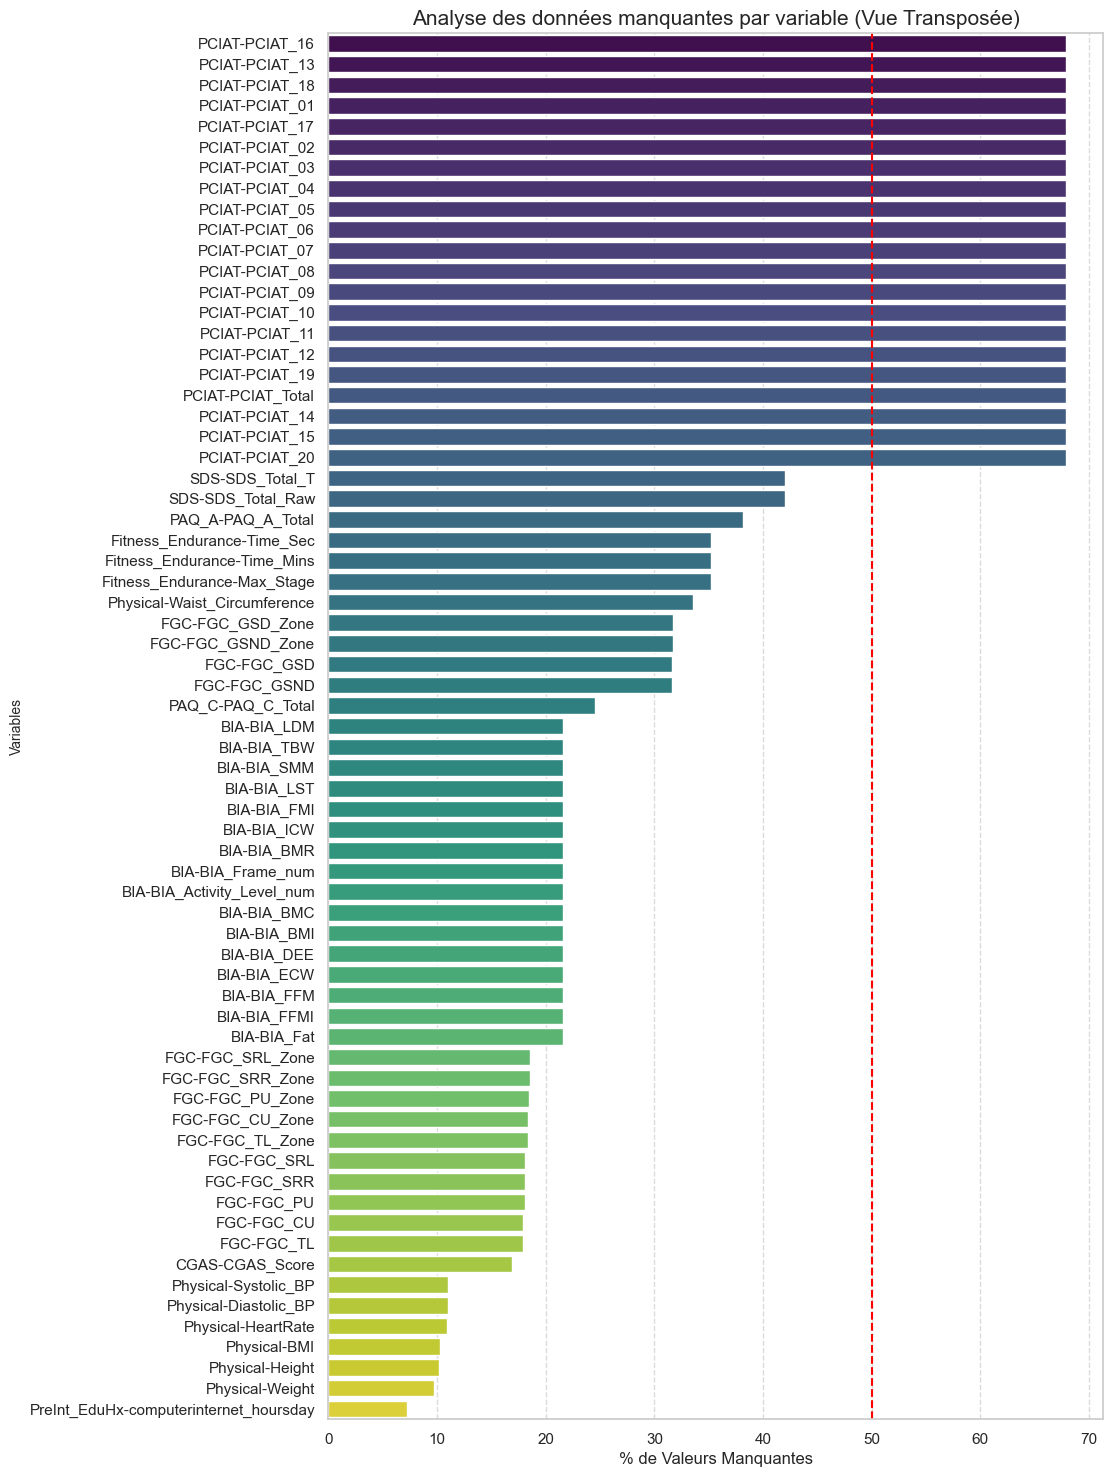

In [30]:
# Distribution of missing values before imputation (Histogram of missing value percentage for each numerical feature)


# 1. Calcul du pourcentage de NaNs (ton code actuel)
missing_pct = numerical_df.isna().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

# 2. Visualisation Transposée
# On augmente la hauteur (figsize) pour laisser de la place aux 71 noms
plt.figure(figsize=(10, 18)) 

# Inversion : x devient le pourcentage, y devient le nom des variables
sns.barplot(x=missing_pct.values, y=missing_pct.index, hue=missing_pct.index, palette="viridis", legend=False)

# Ajout d'une ligne rouge pour le seuil critique (ex: 50%)
plt.axvline(x=50, color='red', linestyle='--', label='Seuil critique (50%)')

plt.title("Analyse des données manquantes par variable (Vue Transposée)", fontsize=15)
plt.xlabel("% de Valeurs Manquantes", fontsize=12)
plt.ylabel("Variables", fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [10]:
# Imputation strategy MissForest
from sklearn.impute import IterativeImputer

df_1 = df.copy()

# 2. Encodage des catégories sur df_1 (pas df)
encoder = OrdinalEncoder()
cat_cols = categorical_cols.columns
df_1[cat_cols] = encoder.fit_transform(df_1[cat_cols])

# 3. Configuration de l'imputeur (Style MissForest optimisé)
# C'est ICI qu'on place n_jobs=-1 pour accélérer le RandomForest
estimateur = RandomForestRegressor(
    n_estimators=10, 
    n_jobs=-1,       # Utilise tous les cœurs du processeur
    random_state=42
)

imputer = IterativeImputer(
    estimator=estimateur,
    random_state=42,
    max_iter=10      # Attention, pas de paramètre n_jobs ici !
)

# 4. Imputation
df_imputed = pd.DataFrame(imputer.fit_transform(df_1), columns=df_1.columns)

# 5. Décodage (avec un petit .astype(int) pour éviter les bugs si l'imputeur renvoie des floats)
df_imputed[cat_cols] = encoder.inverse_transform(df_imputed[cat_cols].round().astype(int))

df_imputed

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,0.0,0.0,5.0,0.0,3.0,51.0,0.0,16.877316,46.00,50.8,...,4.0,2.0,4.0,55.0,1.0,58.55,81.00,0.0,3.0,2.0
1,1.0,2.0,9.0,0.0,1.0,65.8,0.0,14.035590,48.00,46.0,...,0.0,0.0,0.0,0.0,0.0,46.00,64.00,2.0,0.0,0.0
2,2.0,2.0,10.0,1.0,0.0,71.0,0.0,16.648696,56.50,75.6,...,2.0,1.0,1.0,28.0,0.0,38.00,54.00,2.0,2.0,0.0
3,3.0,3.0,9.0,0.0,0.0,71.0,2.0,18.292347,56.00,81.6,...,3.0,4.0,1.0,44.0,2.0,31.00,45.00,3.0,0.0,1.0
4,4.0,1.0,18.0,1.0,2.0,65.0,1.0,17.937682,55.25,77.0,...,0.9,1.2,1.2,26.7,2.0,46.55,65.15,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,8455.0,1.0,7.0,1.0,1.0,64.8,0.0,16.130585,46.07,49.0,...,1.5,1.5,1.5,29.3,2.0,38.50,55.00,1.0,0.0,0.0
8456,8456.0,3.0,10.0,1.0,1.0,69.5,3.0,15.821241,56.13,47.8,...,1.6,2.3,2.0,33.6,1.0,48.00,64.05,3.0,0.0,1.0
8457,8457.0,3.0,10.0,1.0,3.0,70.0,3.0,40.937571,49.56,47.2,...,1.6,1.3,1.1,26.1,1.0,54.85,69.65,1.0,2.0,0.0
8458,8458.0,0.0,15.0,1.0,2.0,55.5,1.0,21.228980,63.79,99.5,...,2.0,3.0,2.1,51.0,3.0,45.70,59.20,0.0,1.0,2.0


In [12]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

df_2 = df.copy()

df = pd.DataFrame(df_2)

# --- ÉTAPE 1 : ENCODAGE DES CATÉGORIES ---
# Le KNN ne comprend que les chiffres. 
# On transforme 'Paris', 'Lyon' en 0, 1, 2...
cat_cols = categorical_cols.columns
num_cols = numerical_cols.columns

encoder = OrdinalEncoder()
# On encode tout en gardant les NaNs (OrdinalEncoder les gère bien depuis peu)
df[cat_cols] = encoder.fit_transform(df[cat_cols])

# --- ÉTAPE 2 : MISE À L'ÉCHELLE (SCALING) ---
# Crucial pour le KNN ! On met tout sur une échelle de 0 à 1 (ou moyenne 0, écart-type 1)
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# --- ÉTAPE 3 : IMPUTATION KNN ---
# n_neighbors=3 : on regarde les 5 voisins les plus proches
imputer = KNNImputer(n_neighbors=5)
df_imputed_scaled = pd.DataFrame(imputer.fit_transform(df_scaled), columns=df.columns)

# --- ÉTAPE 4 : RETOUR AU FORMAT D'ORIGINE ---
# 1. On annule le scaling
df_final = pd.DataFrame(scaler.inverse_transform(df_imputed_scaled), columns=df.columns)

# 2. On annule l'encodage pour retrouver 'Paris', 'Lyon', etc.
# On arrondit d'abord car l'imputeur peut donner des valeurs comme 0.7 (on veut 0 ou 1)
df_final[cat_cols] = encoder.inverse_transform(df_final[cat_cols].round().astype(int))

df_final

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,0.0,0.0,5.0,0.0,3.0,51.0,0.0,16.877316,46.00,50.8,...,4.0,2.0,4.0,5.500000e+01,1.0,46.4,60.1,0.0,3.0,2.000000e+00
1,1.0,2.0,9.0,0.0,2.0,62.4,0.0,14.035590,48.00,46.0,...,0.0,0.0,0.0,3.552714e-15,0.0,46.0,64.0,2.0,0.0,-5.551115e-17
2,2.0,2.0,10.0,1.0,0.0,71.0,0.0,16.648696,56.50,75.6,...,2.0,1.0,1.0,2.800000e+01,0.0,38.0,54.0,2.0,2.0,-5.551115e-17
3,3.0,3.0,9.0,0.0,0.0,71.0,2.0,18.292347,56.00,81.6,...,3.0,4.0,1.0,4.400000e+01,2.0,31.0,45.0,3.0,0.0,1.000000e+00
4,4.0,1.0,18.0,1.0,2.0,65.0,1.0,17.937682,55.00,77.0,...,0.2,0.6,0.6,1.620000e+01,2.0,47.6,66.2,1.0,1.0,-5.551115e-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,8455.0,1.0,7.0,1.0,1.0,61.4,0.0,16.130585,46.07,49.0,...,0.8,0.0,0.0,1.240000e+01,2.0,38.5,55.0,1.0,0.0,-5.551115e-17
8456,8456.0,3.0,10.0,1.0,1.0,69.5,3.0,17.229526,56.13,47.8,...,2.0,1.4,1.0,2.680000e+01,1.0,55.6,58.3,3.0,0.0,1.000000e+00
8457,8457.0,3.0,10.0,1.0,3.0,70.0,3.0,40.937571,49.56,47.2,...,1.6,0.8,1.2,2.580000e+01,1.0,38.1,54.7,1.0,2.0,-5.551115e-17
8458,8458.0,0.0,15.0,1.0,1.0,55.5,1.0,24.832998,63.79,99.5,...,1.8,0.6,1.0,4.560000e+01,1.0,38.1,51.5,0.0,1.0,2.000000e+00


In [ ]:
# Class imbalance profile for the target
class_counts = df[target_col].value_counts().sort_index()
class_pct = (class_counts / class_counts.sum() * 100).round(2)

print('Class counts:')
print(class_counts)
print()
print('Class percentages:')
print(class_pct)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=class_counts.index.astype(int), y=class_counts.values, ax=ax[0], palette='viridis')
ax[0].set_title('Target Distribution (Counts)')
ax[0].set_xlabel('sii class')
ax[0].set_ylabel('count')

ax[1].pie(class_counts.values, labels=class_counts.index.astype(int), autopct='%1.1f%%', startangle=90)
ax[1].set_title('Target Distribution (%)')

plt.tight_layout()
plt.show()


In [ ]:
# Leakage check: PCIAT total score is used to derive severity categories and is strongly tied to sii
pciat_cols = [c for c in df.columns if c.startswith('PCIAT-')]
print('PCIAT columns found:', len(pciat_cols))

if 'PCIAT-PCIAT_Total' in df.columns:
    relation = df[['sii', 'PCIAT-PCIAT_Total']].dropna()
    print('Rows with non-null PCIAT total:', len(relation))
    display(relation.groupby('sii')['PCIAT-PCIAT_Total'].describe()[['count', 'mean', 'min', 'max']])


### 2.1 Feature Sets

We evaluate two feature spaces:
- **full features**: includes `PCIAT-*` variables (high leakage risk)
- **no-leak features**: excludes `PCIAT-*` variables (more realistic prediction setting)


In [ ]:
# Build feature matrices
full_drop = [target_col] + ([id_col] if id_col else [])
X_full = df.drop(columns=full_drop, errors='ignore')

no_leak_drop = full_drop + pciat_cols
X_no_leak = df.drop(columns=no_leak_drop, errors='ignore')

y = df[target_col].astype(int)

print('X_full shape:', X_full.shape)
print('X_no_leak shape:', X_no_leak.shape)


In [ ]:
# Reusable helpers

def make_preprocessor(X):
    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])

    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])

    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ])

    return preprocessor


def fit_eval_classifier(model_name, estimator, X_train, y_train, X_test, y_test):
    preprocessor = make_preprocessor(X_train)

    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', estimator),
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'macro_f1': f1_score(y_test, y_pred, average='macro'),
        'weighted_f1': f1_score(y_test, y_pred, average='weighted'),
    }

    return pipe, y_pred, metrics


def crossval_macro_f1(estimator, X, y, folds=3):
    preprocessor = make_preprocessor(X)
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', estimator),
    ])

    cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE)
    scoring = {
        'macro_f1': 'f1_macro',
        'bal_acc': 'balanced_accuracy',
        'acc': 'accuracy',
    }

    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring)
    return {
        'cv_macro_f1_mean': scores['test_macro_f1'].mean(),
        'cv_macro_f1_std': scores['test_macro_f1'].std(),
        'cv_bal_acc_mean': scores['test_bal_acc'].mean(),
        'cv_acc_mean': scores['test_acc'].mean(),
    }


## 3. Baseline Classification


In [ ]:
# Split data for both tracks
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_full, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_no_leak, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Full train/test:', Xf_train.shape, Xf_test.shape)
print('No-leak train/test:', Xn_train.shape, Xn_test.shape)


In [ ]:
# Baseline models
base_models = {
    'dummy_prior': DummyClassifier(strategy='prior', random_state=RANDOM_STATE),
    'logistic_regression': LogisticRegression(max_iter=1200),
    'decision_tree': DecisionTreeClassifier(random_state=RANDOM_STATE, min_samples_leaf=10),
    'random_forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
}

rows = []
fitted_models = {}
predictions = {}

# Evaluate on FULL feature space
for name, model in base_models.items():
    fit_pipe, y_pred, m = fit_eval_classifier(
        model_name=f'full::{name}',
        estimator=model,
        X_train=Xf_train,
        y_train=yf_train,
        X_test=Xf_test,
        y_test=yf_test,
    )
    rows.append(m)
    fitted_models[m['model']] = fit_pipe
    predictions[m['model']] = y_pred

# Evaluate on NO-LEAK feature space
for name, model in base_models.items():
    fit_pipe, y_pred, m = fit_eval_classifier(
        model_name=f'noleak::{name}',
        estimator=model,
        X_train=Xn_train,
        y_train=yn_train,
        X_test=Xn_test,
        y_test=yn_test,
    )
    rows.append(m)
    fitted_models[m['model']] = fit_pipe
    predictions[m['model']] = y_pred

baseline_comparison = pd.DataFrame(rows).sort_values('macro_f1', ascending=False)
display(baseline_comparison)


In [ ]:
# Cross-validation on the no-leak setting for more robust model selection
cv_rows = []

for name, model in base_models.items():
    cv_stats = crossval_macro_f1(model, X_no_leak, y, folds=3)
    cv_rows.append({'model': f'noleak::{name}', **cv_stats})

cv_df = pd.DataFrame(cv_rows).sort_values('cv_macro_f1_mean', ascending=False)
display(cv_df)


## 4. Outlier Analysis and Treatment

Outlier detection is done on numeric training features using `IsolationForest`, then we compare model quality before/after filtering outliers.


In [ ]:
# Detect outliers on training numeric data (no-leak track)
num_cols_noleak = Xn_train.select_dtypes(include=[np.number]).columns.tolist()
train_num = Xn_train[num_cols_noleak].copy()
train_num = train_num.fillna(train_num.median())

iso = IsolationForest(contamination=0.03, random_state=RANDOM_STATE)
iso_flags = iso.fit_predict(train_num)
inlier_mask = (iso_flags == 1)

Xn_train_inlier = Xn_train.loc[inlier_mask]
yn_train_inlier = yn_train.loc[inlier_mask]

print('Original no-leak training size:', len(Xn_train))
print('Inlier training size:', len(Xn_train_inlier))
print('Removed outliers:', int((~inlier_mask).sum()))


In [ ]:
# Compare outlier handling impact with Decision Tree and Random Forest
outlier_eval_rows = []

for model_name, estimator in {
    'decision_tree': DecisionTreeClassifier(random_state=RANDOM_STATE, min_samples_leaf=10),
    'random_forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
}.items():
    _, _, m_clean = fit_eval_classifier(
        f'noleak_clean::{model_name}', estimator, Xn_train, yn_train, Xn_test, yn_test
    )
    _, _, m_inlier = fit_eval_classifier(
        f'noleak_inlier::{model_name}', estimator, Xn_train_inlier, yn_train_inlier, Xn_test, yn_test
    )
    outlier_eval_rows.extend([m_clean, m_inlier])

outlier_df = pd.DataFrame(outlier_eval_rows).sort_values('macro_f1', ascending=False)
display(outlier_df)


## 5. Imbalanced Learning Strategies (No-Leak Track)


In [ ]:
# Algorithm-level balancing with class weights
weighted_models = {
    'noleak::logreg_weighted': LogisticRegression(max_iter=1200, class_weight='balanced'),
    'noleak::dtree_weighted': DecisionTreeClassifier(random_state=RANDOM_STATE, min_samples_leaf=10, class_weight='balanced'),
    'noleak::rf_weighted': RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced_subsample'
    ),
}

weighted_rows = []
weighted_fitted = {}
weighted_preds = {}

for model_name, estimator in weighted_models.items():
    fit_pipe, y_pred, m = fit_eval_classifier(
        model_name=model_name,
        estimator=estimator,
        X_train=Xn_train,
        y_train=yn_train,
        X_test=Xn_test,
        y_test=yn_test,
    )
    weighted_rows.append(m)
    weighted_fitted[model_name] = fit_pipe
    weighted_preds[model_name] = y_pred

weighted_df = pd.DataFrame(weighted_rows).sort_values('macro_f1', ascending=False)
display(weighted_df)


In [ ]:
# Manual random resampling (train only) so notebook runs without extra libraries

def random_oversample(X_in, y_in, random_state=42):
    rng = np.random.default_rng(random_state)
    work = X_in.copy()
    work['_target_'] = y_in.values

    class_counts = work['_target_'].value_counts()
    majority_size = class_counts.max()

    parts = []
    for cls, count in class_counts.items():
        cls_rows = work[work['_target_'] == cls]
        if count < majority_size:
            extra_idx = rng.choice(cls_rows.index.to_numpy(), size=majority_size - count, replace=True)
            cls_rows = pd.concat([cls_rows, cls_rows.loc[extra_idx]], axis=0)
        parts.append(cls_rows)

    sampled = pd.concat(parts, axis=0).sample(frac=1.0, random_state=random_state)
    return sampled.drop(columns=['_target_']), sampled['_target_'].astype(int)


def random_undersample(X_in, y_in, random_state=42):
    work = X_in.copy()
    work['_target_'] = y_in.values

    class_counts = work['_target_'].value_counts()
    minority_size = class_counts.min()

    parts = []
    for cls in class_counts.index:
        cls_rows = work[work['_target_'] == cls].sample(n=minority_size, replace=False, random_state=random_state)
        parts.append(cls_rows)

    sampled = pd.concat(parts, axis=0).sample(frac=1.0, random_state=random_state)
    return sampled.drop(columns=['_target_']), sampled['_target_'].astype(int)


X_over, y_over = random_oversample(Xn_train, yn_train, random_state=RANDOM_STATE)
X_under, y_under = random_undersample(Xn_train, yn_train, random_state=RANDOM_STATE)

print('Original class distribution:')
print(yn_train.value_counts().sort_index())
print()
print('Oversampled class distribution:')
print(y_over.value_counts().sort_index())
print()
print('Undersampled class distribution:')
print(y_under.value_counts().sort_index())


In [ ]:
# Evaluate resampling strategies with Random Forest
resampling_rows = []

rf_est = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)

_, y_pred_over, m_over = fit_eval_classifier(
    model_name='noleak::rf_oversampled',
    estimator=rf_est,
    X_train=X_over,
    y_train=y_over,
    X_test=Xn_test,
    y_test=yn_test,
)

_, y_pred_under, m_under = fit_eval_classifier(
    model_name='noleak::rf_undersampled',
    estimator=rf_est,
    X_train=X_under,
    y_train=y_under,
    X_test=Xn_test,
    y_test=yn_test,
)

resampling_rows.extend([m_over, m_under])
resampling_df = pd.DataFrame(resampling_rows).sort_values('macro_f1', ascending=False)
display(resampling_df)


## 6. Final Classification Comparison and Diagnostics


In [ ]:
# Collect no-leak models in one comparison table
noleak_baselines = baseline_comparison[baseline_comparison['model'].str.startswith('noleak::')]

all_cls_results = pd.concat(
    [noleak_baselines, weighted_df, resampling_df],
    ignore_index=True
).sort_values('macro_f1', ascending=False)

display(all_cls_results)

plot_data = all_cls_results[['model', 'macro_f1', 'balanced_accuracy']].set_index('model')
plot_data.plot(kind='bar', figsize=(14, 6), colormap='Set2')
plt.title('No-Leak Classification Comparison')
plt.ylabel('score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# Refit the best no-leak model and inspect class-level performance
best_model_name = all_cls_results.iloc[0]['model']

model_factory = {
    'noleak::dummy_prior': DummyClassifier(strategy='prior', random_state=RANDOM_STATE),
    'noleak::logistic_regression': LogisticRegression(max_iter=1200),
    'noleak::decision_tree': DecisionTreeClassifier(random_state=RANDOM_STATE, min_samples_leaf=10),
    'noleak::random_forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'noleak::logreg_weighted': LogisticRegression(max_iter=1200, class_weight='balanced'),
    'noleak::dtree_weighted': DecisionTreeClassifier(random_state=RANDOM_STATE, min_samples_leaf=10, class_weight='balanced'),
    'noleak::rf_weighted': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced_subsample'),
    'noleak::rf_oversampled': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'noleak::rf_undersampled': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
}

# Use matching train data for resampling variants
if best_model_name == 'noleak::rf_oversampled':
    X_train_best, y_train_best = X_over, y_over
elif best_model_name == 'noleak::rf_undersampled':
    X_train_best, y_train_best = X_under, y_under
else:
    X_train_best, y_train_best = Xn_train, yn_train

best_estimator = model_factory[best_model_name]
best_pipe, best_pred, best_metrics = fit_eval_classifier(
    model_name=best_model_name,
    estimator=best_estimator,
    X_train=X_train_best,
    y_train=y_train_best,
    X_test=Xn_test,
    y_test=yn_test,
)

print('Best model:', best_model_name)
print(best_metrics)
print()
print(classification_report(yn_test, best_pred, digits=3))

labels = sorted(y.unique())
cm = confusion_matrix(yn_test, best_pred, labels=labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()


In [ ]:
# Explainability: permutation feature importance on best no-leak model
perm = permutation_importance(
    estimator=best_pipe,
    X=Xn_test,
    y=yn_test,
    scoring='f1_macro',
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

fi = pd.DataFrame({
    'feature': Xn_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

display(fi.head(20))

plt.figure(figsize=(12, 6))
sns.barplot(data=fi.head(20), x='importance_mean', y='feature', palette='crest')
plt.title('Top 20 Permutation Importances (Macro-F1)')
plt.xlabel('Importance (mean decrease)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## 7. Advanced Regression Task (Extra)

We model a continuous target: `SDS-SDS_Total_T`.

Leakage prevention for regression:
- remove `SDS-SDS_Total_Raw` (directly related score)
- remove `PCIAT-*` columns


In [ ]:
reg_target = 'SDS-SDS_Total_T'

reg_df = df[df[reg_target].notna()].copy()
reg_drop = [id_col, reg_target, 'SDS-SDS_Total_Raw'] + pciat_cols
reg_drop = [c for c in reg_drop if c is not None]

X_reg = reg_df.drop(columns=reg_drop, errors='ignore')
y_reg = reg_df[reg_target].astype(float)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print('Regression rows used:', len(reg_df))
print('Regression train/test:', Xr_train.shape, Xr_test.shape)


In [ ]:
# Regression helper

def fit_eval_regressor(model_name, estimator, X_train, y_train, X_test, y_test):
    preprocessor = make_preprocessor(X_train)

    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', estimator),
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    rmse = mean_squared_error(y_test, pred) ** 0.5

    metrics = {
        'model': model_name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': rmse,
        'R2': r2_score(y_test, pred),
    }

    return pipe, pred, metrics


reg_models = {
    'dummy_mean': DummyRegressor(strategy='mean'),
    'rf_regressor': RandomForestRegressor(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1),
    'gbr_regressor': GradientBoostingRegressor(random_state=RANDOM_STATE),
}

reg_rows = []
for name, model in reg_models.items():
    _, _, m = fit_eval_regressor(name, model, Xr_train, yr_train, Xr_test, yr_test)
    reg_rows.append(m)

reg_results = pd.DataFrame(reg_rows).sort_values('RMSE')
display(reg_results)


## 8. Clustering Analysis (Extra)

Unsupervised clustering on no-leak **numeric** features:
- median imputation + standardization
- silhouette-based selection of `k`
- 2D PCA visualization


In [ ]:
num_cols = X_no_leak.select_dtypes(include=[np.number]).columns.tolist()
X_num = X_no_leak[num_cols].copy()

imp = SimpleImputer(strategy='median')
X_num_imp = imp.fit_transform(X_num)

sc = StandardScaler()
X_num_scaled = sc.fit_transform(X_num_imp)

sil_rows = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_num_scaled)
    sil = silhouette_score(X_num_scaled, labels)
    sil_rows.append({'k': k, 'silhouette': sil})

sil_df = pd.DataFrame(sil_rows).sort_values('silhouette', ascending=False)
display(sil_df)

best_k = int(sil_df.iloc[0]['k'])
print('Best k from silhouette:', best_k)


In [ ]:
# Fit clustering with best k and visualize clusters in 2D
km_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
cluster_labels = km_best.fit_predict(X_num_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_num_scaled)

plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'cluster': cluster_labels,
    'sii': y.values,
})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='cluster', palette='tab10', s=35, alpha=0.8)
plt.title('KMeans Clusters (PCA projection)')
plt.tight_layout()
plt.show()

cluster_sii = pd.crosstab(plot_df['cluster'], plot_df['sii'], normalize='index').round(3)
print('Class composition per cluster (row-normalized):')
display(cluster_sii)


## 9. Final Conclusions

Key findings:
- `sii` is strongly imbalanced, so `macro_f1` and `balanced_accuracy` are required.
- `PCIAT-*` variables create strong leakage risk when predicting `sii`; no-leak analysis is more realistic.
- in the no-leak setting, model performance is significantly harder and closer to baseline, which is expected.
- outlier filtering can be evaluated but may not always improve multiclass metrics.
- class weighting and sampling strategies should be compared empirically because gains vary by model and class.
- additional regression and clustering analyses provide broader project coverage and exploratory insight.

Possible next upgrades:
1. hyperparameter tuning with `GridSearchCV`/`RandomizedSearchCV`
2. advanced resampling (SMOTE/ADASYN) if `imbalanced-learn` is installed
3. threshold/cost-sensitive optimization targeting minority classes
